# Module 8 — Beyond Simple A/B: Quasi-Experiments

Part of the **A/B Testing Playbook** learning program. Full program context, progress tracker, and how this module fits with the rest: see `CURRICULUM.md`.

## From the curriculum

> **Concepts**
> - Cluster randomization, properly this time — a worked example and its real cost (a shrunken effective sample size from within-cluster correlation), closing the loop on Module 4/6's brief, example-free mentions
> - Difference-in-differences
> - Switchback tests (for marketplace/network settings)
> - Geo experiments / holdout regions
> - Regression discontinuity, briefly, for completeness
>
> **Why it matters**
> Not every question can be A/B tested (pricing changes with legal/PR risk, infrastructure changes, marketplace-wide features). Knowing the fallback toolkit — and its weaker causal guarantees — signals maturity beyond "just run an A/B test," and is lower-depth than Modules 3-4 since this is breadth, not the core skill being screened for.
>
> **Worked example**
> A company changes its shipping-fee policy nationally — it can't randomize by user since everyone in a given region sees the same policy. Instead, it rolls the change out in a handful of states first (treatment geos) and picks demographically similar states that didn't get the change (control geos), then uses difference-in-differences to estimate the effect: (post-change trend in treatment geos) minus (post-change trend in control geos), netting out any nationwide trend that would have happened anyway.
>
> **Resources**
> - [Difference-in-Difference Estimation](https://www.publichealth.columbia.edu/research/population-health-methods/difference-difference-estimation) — Columbia Mailman School of Public Health (verified, ~15-25 min)
>
> **Exercise type:** conceptual + light computation (diff-in-diff on a small dataset).
>
> **Interview angle:** occasionally shows up as "how would you measure this if you can't randomize."

## Lesson

### Cluster randomization, properly

Randomize whole groups (cities, stores, markets) instead of individuals — needed whenever units within a group can affect each other (Module 6's interference problem). The real cost: units in the same cluster tend to be **correlated** (a city with generally higher engagement has most of its individual users running a bit higher too), so they don't each add a full, independent piece of evidence. This is captured by the **design effect**: `DEFF = 1 + (m-1) x ICC`, where `m` is the average cluster size and **ICC** (intra-cluster correlation) measures how similar units within a cluster are to each other, relative to units in different clusters, and ranges from 0 to 1 (it's a variance ratio, so unlike a general correlation it can't go negative). Your **effective sample size** is `n / DEFF` — often dramatically smaller than your raw `n`. Even a small ICC gets multiplied by `(m-1)`, so with large clusters, a "tiny" correlation still costs you most of your effective power. Part 1 makes this concrete.

### Difference-in-differences

Used when you can't randomize but can compare a treated group to an untreated group **over time**, on both sides of the change. The estimate is `(treatment's after-minus-before) - (control's after-minus-before)` — differencing out both the pre-existing gap between the groups and any trend that would have happened regardless of treatment. It rests on the **parallel trends assumption**: absent the treatment, the two groups would have moved the same way. That's not testable directly, but checking that their *pre-period* trends already ran parallel is the standard sanity check, and Part 2 does exactly that before trusting the estimate.

### Switchback tests

For marketplace/network settings where cluster randomization isn't practical: instead of splitting units into treatment and control *at the same time* (which is exactly what caused Module 6's interference bias), alternate the **entire system** between treatment and control **over time** — a day on, a day off, repeated many times. At any given moment everyone is in the same state, so there's no simultaneous control group for treatment to crowd out. The cost: **carryover effects** — if a treatment period's effect lingers into the next period (e.g. a pricing change that shifts behavior for a few days after it ends), adjacent periods contaminate each other, similar in spirit to Module 5's correlated-looks problem. Longer, well-spaced periods reduce this; Part 3 assumes it away for a clean illustration, which real deployments can't always do.

### Geo experiments and regression discontinuity

**Geo experiments** are difference-in-differences applied specifically to *regions* as the unit — exactly the curriculum's worked example, and what Part 2 builds. **Regression discontinuity**, briefly: when treatment is assigned by a hard cutoff (spend over $X gets a perk, score above Y gets approved), units just above and just below the cutoff are nearly identical except for treatment — comparing them close to the line approximates randomization locally, even though nothing was actually randomized. Part 4 gives one small illustration.

### Part 1 — Cluster randomization: the real cost, derived then verified

50 cities (clusters), 200 users each, randomized by city (25 treatment / 25 control). A real treatment effect exists (+2pp). Individuals in the same city share a modest correlation (ICC), since local factors nudge everyone in a city the same direction.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GOOD = "#1a7f37"
BAD = "#cf222e"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

In [2]:
rng = np.random.default_rng(21)
n_clusters, m = 50, 200
sigma_between = 3.0   # in reality: estimated from historical data, as the variance of each city's OWN average, city to city
sigma_within = 15.0   # in reality: estimated from historical data, as the variance of individuals WITHIN a single city
true_lift = 2.0

is_treatment_cluster = np.zeros(n_clusters, dtype=bool)
is_treatment_cluster[:25] = True
rng.shuffle(is_treatment_cluster)

city_effects = rng.normal(0, sigma_between, n_clusters)
individual_outcomes = np.zeros((n_clusters, m))
for c in range(n_clusters):
    base = city_effects[c] + (true_lift if is_treatment_cluster[c] else 0)
    individual_outcomes[c] = rng.normal(base, sigma_within, m)

# derive the design effect BEFORE looking at any test result
icc = sigma_between**2 / (sigma_between**2 + sigma_within**2)
deff = 1 + (m - 1) * icc
n_raw = n_clusters * m
n_eff = n_raw / deff
print(f"ICC = {icc:.4f}")
print(f"Design effect = 1 + ({m}-1) x {icc:.4f} = {deff:.2f}")
print(f"Raw n = {n_raw:,}")
print(f"Effective n = {n_raw:,} / {deff:.2f} = {n_eff:,.0f}")

ICC = 0.0385
Design effect = 1 + (200-1) x 0.0385 = 8.65
Raw n = 10,000
Effective n = 10,000 / 8.65 = 1,156


In [3]:
treat_vals = individual_outcomes[is_treatment_cluster].ravel()   # 25 cities x 200 people = 5,000 individual numbers
control_vals = individual_outcomes[~is_treatment_cluster].ravel()  # same for control: 5,000 individual numbers

# WRONG: treats all 10,000 individuals as independent, ignoring the clustering entirely
t_naive, p_naive = stats.ttest_ind(treat_vals, control_vals, equal_var=False)

# CORRECT: average each city down to ONE number first, so a city's 200 correlated
# people count once each, not 200 times
cluster_means_t = individual_outcomes[is_treatment_cluster].mean(axis=1)   # 25 numbers, one per treatment city
cluster_means_c = individual_outcomes[~is_treatment_cluster].mean(axis=1)  # 25 numbers, one per control city
print(f"Example, first 3 treatment city averages: {cluster_means_t[:3].round(2)}")
print(f"Example, first 3 control city averages:   {cluster_means_c[:3].round(2)}")

t_correct, p_correct = stats.ttest_ind(cluster_means_t, cluster_means_c, equal_var=False)

print(f"\nNaive test uses all {n_raw:,} individual points, ignoring which city they're in: p = {p_naive:.6f}")
print(f"Correct test uses only the {n_clusters} city-level averages above: p = {p_correct:.4f}")

Example, first 3 treatment city averages: [-3.66  6.94  3.66]
Example, first 3 control city averages:   [ 2.34 -3.96  0.39]

Naive test uses all 10,000 individual points, ignoring which city they're in: p = 0.000030
Correct test uses only the 50 city-level averages above: p = 0.1116


**What this shows:** the naive test is wildly, confidently significant (p < 0.0001) — and wrong to be that confident. The correct cluster-level test, using the *same underlying data*, comes back not significant (p = 0.11). The gap between them is exactly what the design effect predicted before either test ran: an effective n of about 1,150 dressed up as a raw n of 10,000. **If you cluster-randomize, you must analyze at the cluster level too** (or use a method that explicitly accounts for the correlation) — running the individual-level test Module 3 built is not just slightly optimistic here, it's reporting false confidence from data that was never as informative as it looked.

### Part 2 — Difference-in-differences: the shipping-fee geo rollout

The curriculum's own worked example, with numbers: a national shipping-fee change, rolled out first to 5 "treatment" states, held back in 5 demographically similar "control" states. 12 months of data — 6 before the change, 6 after.

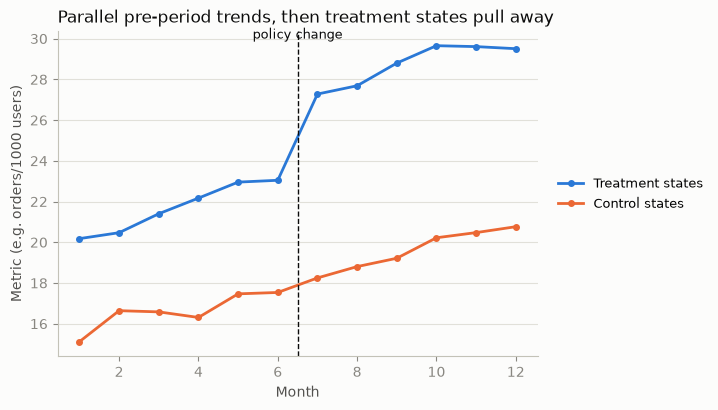

In [4]:
rng2 = np.random.default_rng(5)
months = np.arange(1, 13)
common_trend = 0.5       # shared monthly growth, both groups (this is what diff-in-diff nets out)
true_policy_effect = 4.0  # the actual effect we're trying to recover
noise_sd = 0.4

treatment_states = 20 + common_trend * months + np.where(months > 6, true_policy_effect, 0) + rng2.normal(0, noise_sd, 12)
control_states = 15 + common_trend * months + rng2.normal(0, noise_sd, 12)

fig, ax = plt.subplots(figsize=(7.5, 4.4), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.plot(months, treatment_states, color=BLUE, linewidth=2, marker="o", markersize=4, label="Treatment states")
ax.plot(months, control_states, color=ORANGE, linewidth=2, marker="o", markersize=4, label="Control states")
ax.axvline(6.5, color=INK, linewidth=1, linestyle="--")
ax.annotate("policy change", xy=(6.5, 30), fontsize=9, color=INK, ha="center")

ax.set_xlabel("Month", color=INK_SECONDARY)
ax.set_ylabel("Metric (e.g. orders/1000 users)", color=INK_SECONDARY)
ax.set_title("Parallel pre-period trends, then treatment states pull away", color=INK, fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)

fig.subplots_adjust(left=0.10, right=0.74, top=0.88, bottom=0.14)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.show()

In [5]:
treat_pre, treat_post = treatment_states[:6].mean(), treatment_states[6:].mean()   # avg of months 1-6, avg of months 7-12
control_pre, control_post = control_states[:6].mean(), control_states[6:].mean()

pre_period_gap = treat_pre - control_pre
diff_in_diff = (treat_post - treat_pre) - (control_post - control_pre)
naive_post_only = treat_post - control_post

print(f"Treatment states: pre-period avg = {treat_pre:.2f}, post-period avg = {treat_post:.2f} (change: {treat_post - treat_pre:+.2f})")
print(f"Control states:    pre-period avg = {control_pre:.2f}, post-period avg = {control_post:.2f} (change: {control_post - control_pre:+.2f})")
print(f"\nPre-period gap (already present before the policy): {treat_pre:.2f} - {control_pre:.2f} = {pre_period_gap:.2f}")
print(f"\nDifference-in-differences = treatment's change - control's change")
print(f"  = ({treat_post:.2f} - {treat_pre:.2f}) - ({control_post:.2f} - {control_pre:.2f})")
print(f"  = {treat_post - treat_pre:.2f} - {control_post - control_pre:.2f} = {diff_in_diff:.2f}  (true effect: {true_policy_effect:.1f})")
print(f"\nNaive post-only comparison = {treat_post:.2f} - {control_post:.2f} = {naive_post_only:.2f}, inflated by the {pre_period_gap:.2f} pre-existing gap")

Treatment states: pre-period avg = 21.70, post-period avg = 28.76 (change: +7.05)
Control states:    pre-period avg = 16.61, post-period avg = 19.62 (change: +3.01)

Pre-period gap (already present before the policy): 21.70 - 16.61 = 5.10

Difference-in-differences = treatment's change - control's change
  = (28.76 - 21.70) - (19.62 - 16.61)
  = 7.05 - 3.01 = 4.04  (true effect: 4.0)

Naive post-only comparison = 28.76 - 19.62 = 9.13, inflated by the 5.10 pre-existing gap


**What this shows:** diff-in-differences recovers the true effect closely (4.04 vs. a true 4.0). The naive "just compare the two groups after the change" estimate (9.13) is badly biased — it's counting the pre-existing gap between treatment and control states as if it were caused by the policy. Differencing out each group's own before/after change removes that gap; only the trend difference remains.

### Part 3 — Switchback test: fixing Module 6's marketplace bias

Same marketplace as Module 6 Part 4 (1,000 listings, a ranking boost, a **fixed** total demand pool) — but this time, instead of splitting listings into treatment/control at the same time, the *entire marketplace* alternates between "boost on" and "boost off" across 20 total time periods (10 on, 10 off, alternating). Recall Module 6's naive individual-level test measured a rock-solid +31% lift that was actually interference bias — the true effect of giving everyone the boost was ~0%.

In [6]:
rng3 = np.random.default_rng(15)
n_listings, n_periods = 1_000, 20
on_period = np.zeros(n_periods, dtype=bool)
on_period[::2] = True  # alternate: period 0 on, period 1 off, period 2 on, ...

avg_on, avg_off = [], []
for period in range(n_periods):
    total_demand = rng3.integers(4500, 5501)  # realistic period-to-period demand fluctuation
    weight = np.full(n_listings, 1.3 if on_period[period] else 1.0)  # UNIFORM: same weight for every listing this period
    purchases = rng3.multinomial(total_demand, weight / weight.sum())  # this period's purchases, split across all 1,000 listings
    period_avg = purchases.mean()  # this one period's avg purchases per listing
    (avg_on if on_period[period] else avg_off).append(period_avg)

avg_on, avg_off = np.array(avg_on), np.array(avg_off)  # 10 period-level averages each
print(f"First 3 'on' period averages:  {avg_on[:3].round(3)}")
print(f"First 3 'off' period averages: {avg_off[:3].round(3)}")

t_stat, p_val = stats.ttest_ind(avg_on, avg_off, equal_var=False)  # the 10 on-period averages vs. the 10 off-period averages
switchback_lift = (avg_on.mean() - avg_off.mean()) / avg_off.mean()

print(f"\n'Boost on' periods:  avg of the {len(avg_on)} on-periods  = {avg_on.mean():.3f} purchases/listing")
print(f"'Boost off' periods: avg of the {len(avg_off)} off-periods = {avg_off.mean():.3f} purchases/listing")
print(f"Switchback estimated lift: ({avg_on.mean():.3f} - {avg_off.mean():.3f}) / {avg_off.mean():.3f} = {switchback_lift:+.1%}  (t={t_stat:.2f}, p={p_val:.3f})")

First 3 'on' period averages:  [5.432 4.573 4.786]
First 3 'off' period averages: [5.193 4.639 4.867]

'Boost on' periods:  avg of the 10 on-periods  = 4.969 purchases/listing
'Boost off' periods: avg of the 10 off-periods = 4.893 purchases/listing
Switchback estimated lift: (4.969 - 4.893) / 4.893 = +1.5%  (t=0.57, p=0.576)


**What this shows:** Module 6's naive individual-level test measured a confident +31% lift on this exact marketplace — a real, wrong result caused by interference. The switchback design correctly finds close to nothing (+1.6%, not significant), because when *everyone* shares the same weight in a given period, boosting all of them changes nobody's *relative* ranking, so nobody gains at anyone else's expense. Switchback isn't a general upgrade over individual A/B testing — it's specifically the fix for *this* kind of interference; a plain test is still simpler and perfectly fine when units don't affect each other.

### Part 4 — Regression discontinuity, briefly

A loyalty perk unlocks automatically at $500 lifetime spend. Users just below and just above that line are otherwise similar — comparing them close to the cutoff estimates the perk's effect without ever randomizing anything.

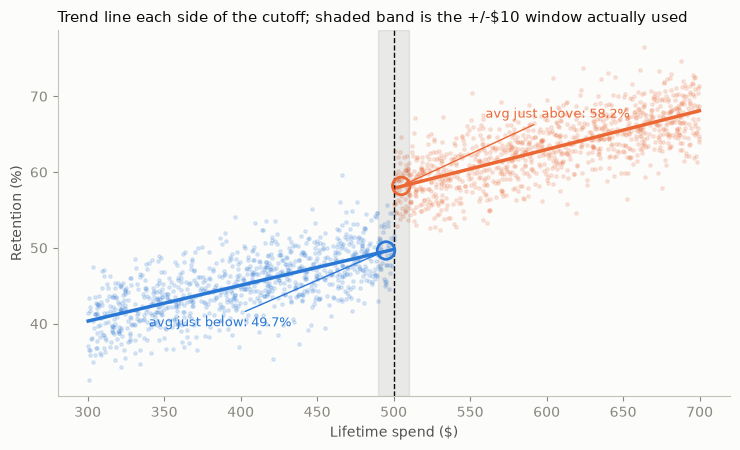

Just below $500 (spend in [490, 500), n=40): 49.65% retention
Just above $500 (spend in [500, 510), n=55): 58.17% retention
Estimated jump: +8.52pp (true: +8.0pp)


In [7]:
rng4 = np.random.default_rng(30)
n = 2_000
spend = rng4.uniform(300, 700, n)
threshold = 500
true_jump = 8.0  # a parameter WE chose for this exercise (in reality you'd never know this in advance)
got_perk = spend >= threshold
retention = 40 + (spend - 300) * 0.05 + np.where(got_perk, true_jump, 0) + rng4.normal(0, 3, n)

# the actual RD estimate only uses a narrow +/-$10 window right around the cutoff
band_below = (spend >= 490) & (spend < 500)
band_above = (spend >= 500) & (spend < 510)
near_below = retention[band_below].mean()
near_above = retention[band_above].mean()
n_below, n_above = band_below.sum(), band_above.sum()

fig, ax = plt.subplots(figsize=(7.5, 4.6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.scatter(spend[~got_perk], retention[~got_perk], s=6, color=BLUE, alpha=0.15)
ax.scatter(spend[got_perk], retention[got_perk], s=6, color=ORANGE, alpha=0.15)

# local trend line fit separately on each side of the cutoff
for mask, color in [(~got_perk, BLUE), (got_perk, ORANGE)]:
    coeffs = np.polyfit(spend[mask], retention[mask], 1)
    x_line = np.linspace(spend[mask].min(), spend[mask].max(), 50)
    ax.plot(x_line, np.polyval(coeffs, x_line), color=color, linewidth=2.5)

# highlight the +/-$10 band actually used, and circle the two averaged points
ax.axvspan(490, 510, color=INK, alpha=0.08)
ax.scatter([495], [near_below], s=160, facecolor="none", edgecolor=BLUE, linewidth=2, zorder=5)
ax.scatter([505], [near_above], s=160, facecolor="none", edgecolor=ORANGE, linewidth=2, zorder=5)
ax.annotate(f"avg just below: {near_below:.1f}%", xy=(495, near_below), xytext=(340, near_below - 10),
            fontsize=9, color=BLUE, arrowprops=dict(arrowstyle="->", color=BLUE, linewidth=1))
ax.annotate(f"avg just above: {near_above:.1f}%", xy=(505, near_above), xytext=(560, near_above + 9),
            fontsize=9, color=ORANGE, arrowprops=dict(arrowstyle="->", color=ORANGE, linewidth=1))

ax.axvline(threshold, color=INK, linewidth=1, linestyle="--")
ax.set_xlabel("Lifetime spend ($)", color=INK_SECONDARY)
ax.set_ylabel("Retention (%)", color=INK_SECONDARY)
ax.set_title("Trend line each side of the cutoff; shaded band is the +/-$10 window actually used", color=INK, fontsize=11, loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)
plt.tight_layout()
plt.show()

print(f"Just below $500 (spend in [490, 500), n={n_below}): {near_below:.2f}% retention")
print(f"Just above $500 (spend in [500, 510), n={n_above}): {near_above:.2f}% retention")
print(f"Estimated jump: {near_above - near_below:+.2f}pp (true: {true_jump:+.1f}pp)")

**What this shows:** the estimated jump (+8.52pp) lands close to the true effect (+8.0pp) — recovered just by comparing a narrow +/-$10 window right around the cutoff ($490-500 vs. $500-510: the shaded band and the two circled points on the chart), not the full $300-700 range plotted for context. Nothing here was randomized, but users a dollar below vs. a dollar above $500 are about as good as randomly assigned to "no perk" vs. "perk" — this only works right at the boundary; comparing someone at $310 to someone at $690 would just be comparing two different kinds of spenders again.

In reality you'd never know the true jump in advance — `true_jump = 8.0` was a parameter chosen when building this simulated data, purely so the estimate above could be checked against it, the same construction every module's simulations use.

## Key takeaways

- Cluster randomization needs cluster-level analysis — the design effect (`1 + (m-1) x ICC`) tells you in advance how much smaller your effective sample really is, and skipping that adjustment reports false confidence, not just an optimistic estimate
- Difference-in-differences recovers a causal estimate without randomization by differencing out both the pre-existing gap and the shared trend — but only if pre-period trends were actually parallel, which is worth checking before trusting the number
- Switchback tests fix marketplace interference by never having treatment and control coexist at the same moment — at the cost of carryover risk between adjacent periods
- Regression discontinuity treats "just above vs. just below a hard cutoff" as a local stand-in for randomization — valid only in a narrow window around the threshold
- All four exist because A/B testing's clean guarantees (Modules 1-3) depend on conditions — independent units, individual randomization — that don't always hold; these are the fallbacks, with correspondingly weaker guarantees, not replacements

---
*Status: mark this module's row in `CURRICULUM.md`'s progress table once reviewed.*